<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Building a CNN: Filters, Layers, Flattening, and Receptive Field**


Now that you understand how filters can be applied to image channels using different padding methods, strides, and activation functions, let us move to the next level.

What happens when we use multiple filters or multiple convolution layers?

Similar to a regular neural network with many neurons, a CNN can contain multiple convolution layers. In addition, each layer can contain multiple filters (kernels) that learn different image features.

In this lab, we will explore how a CNN processes multiple channels, filters, and layers. We will also learn how to flatten the final output so it can be used as input to a standard neural network.


## __Table of Contents__

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
    3. [Defining Helper Functions](#toc-defining-helper-functions)
3. [Deeper Networks and the Receptive Field: Relating Input to Output](#toc-deeper-networks-and-the-receptive-field-relating-input-to-output)
    1. [Why Do We Add More Layers to a CNN?](#toc-why-do-we-add-more-layers-to-a-cnn)
    2. [Why Is a Larger Receptive Field Important?](#toc-why-is-a-larger-receptive-field-important)
    3. [Factors That Affect Receptive Field Size](#toc-factors-that-affect-receptive-field-size)
    4. [Model 1: Default Stride (1,1)](#toc-model-1-default-stride-1-1))
    5. [Model 2: Increased Stride](#toc-model-2-increased-stride)
    6. [Model 3: Increased Layers](#toc-model-3-increased-layers)
    7. [Visualizing the Outputs](#toc-visualizing-the-outputs)
4. [Varied Input-Output Relationships](#toc-varied-input-output-relationships)
    1. [Single Input, Multiple Outputs](#toc-single-input-multiple-outputs)
    2. [Multiple Inputs, Single Output](#toc-multiple-inputs-single-output)
    3. [Multiple Inputs, Multiple Outputs](#toc-multiple-inputs-multiple-outputs)
5. [Deeper CNNs](#toc-deeper-cnns)
    1. [Why do we want multiple layers?](#toc-why-do-we-want-multiple-layers)
    2. [Example: Preparing a CNN for Flower Classification](#toc-example-preparing-a-cnn-for-flower-classification)
    3. [Flattening](#toc-flattening)
    4. [Dense Layers](#toc-dense-layers)


## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

 - Understand the relationship between features and receptive field size
 - Apply filters on inputs of varying depth and calculate output size
 - Build CNNs with greater depth to learn more features and prepare for image classification


----


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the folowing code cell.


In [65]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


### Importing Required Libraries <a id="toc-importing-required-libraries"></a>

_We recommend you import all required libraries in one place (here):_


In [66]:
# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn
warnings.filterwarnings("ignore")

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = (
    "2"  # tensorflow INFO and WARNING messages are not printed
)

In [67]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import PIL
from PIL import ImageOps
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

%matplotlib inline

### **Defining Helper Functions** <a id="toc-defining-helper-functions"></a>


In [68]:
def calc_rf(model):
    # Initialize an array storing all the layers' receptive field sizes and set layer 0 (input) RF to 1
    num_layers = len(model.layers)
    rf_arr = np.empty(num_layers + 1, dtype=int)
    rf_arr[0] = 1
    # Initialize an array storing all the layers' jump sizes and set layer 0 (input) jump to 1
    j_arr = np.empty(num_layers + 1, dtype=int)
    j_arr[0] = 1

    for i in range(num_layers):
        layer = model.layers[i]
        k = layer.kernel_size[0]
        s = layer.strides[0]
        j_in = j_arr[i]
        j_out = j_in * s
        r_out = rf_arr[i] + (k - 1) * j_in
        j_arr[i + 1] = j_out
        rf_arr[i + 1] = r_out
        print(
            "Layer {}: {} \n Jump Size: {}\n Effective Receptive Field Size: {}".format(
                i + 1, layer.name, j_arr[i + 1], rf_arr[i + 1]
            )
        )
        print("------")

## **Deeper Networks and the Receptive Field: Relating Input to Output** <a id="toc-deeper-networks-and-the-receptive-field-relating-input-to-output"></a>


### **Why Do We Add More Layers to a CNN?** <a id="toc-why-do-we-add-more-layers-to-a-cnn"></a>

A CNN feature is calculated from a small region of the previous layer. The part of the original image that can affect one feature is called its **receptive field (RF)**.

With a `3×3` kernel, one feature in the first convolution layer can depend on a `3×3` region of the input image.

When we stack convolution layers, each new feature combines nearby features from the previous layer. Because those previous features already depend on the original image, deeper features can use information from a larger image region.

The **theoretical RF** is the full region that can affect a feature. The **effective RF (ERF)** shows how strongly each pixel in that region affects the feature. Usually, pixels near the center have stronger influence.



The figure below shows the same idea visually: valid convolutions shrink the feature map, while the receptive field grows from `3×3` to `5×5` to `7×7`.

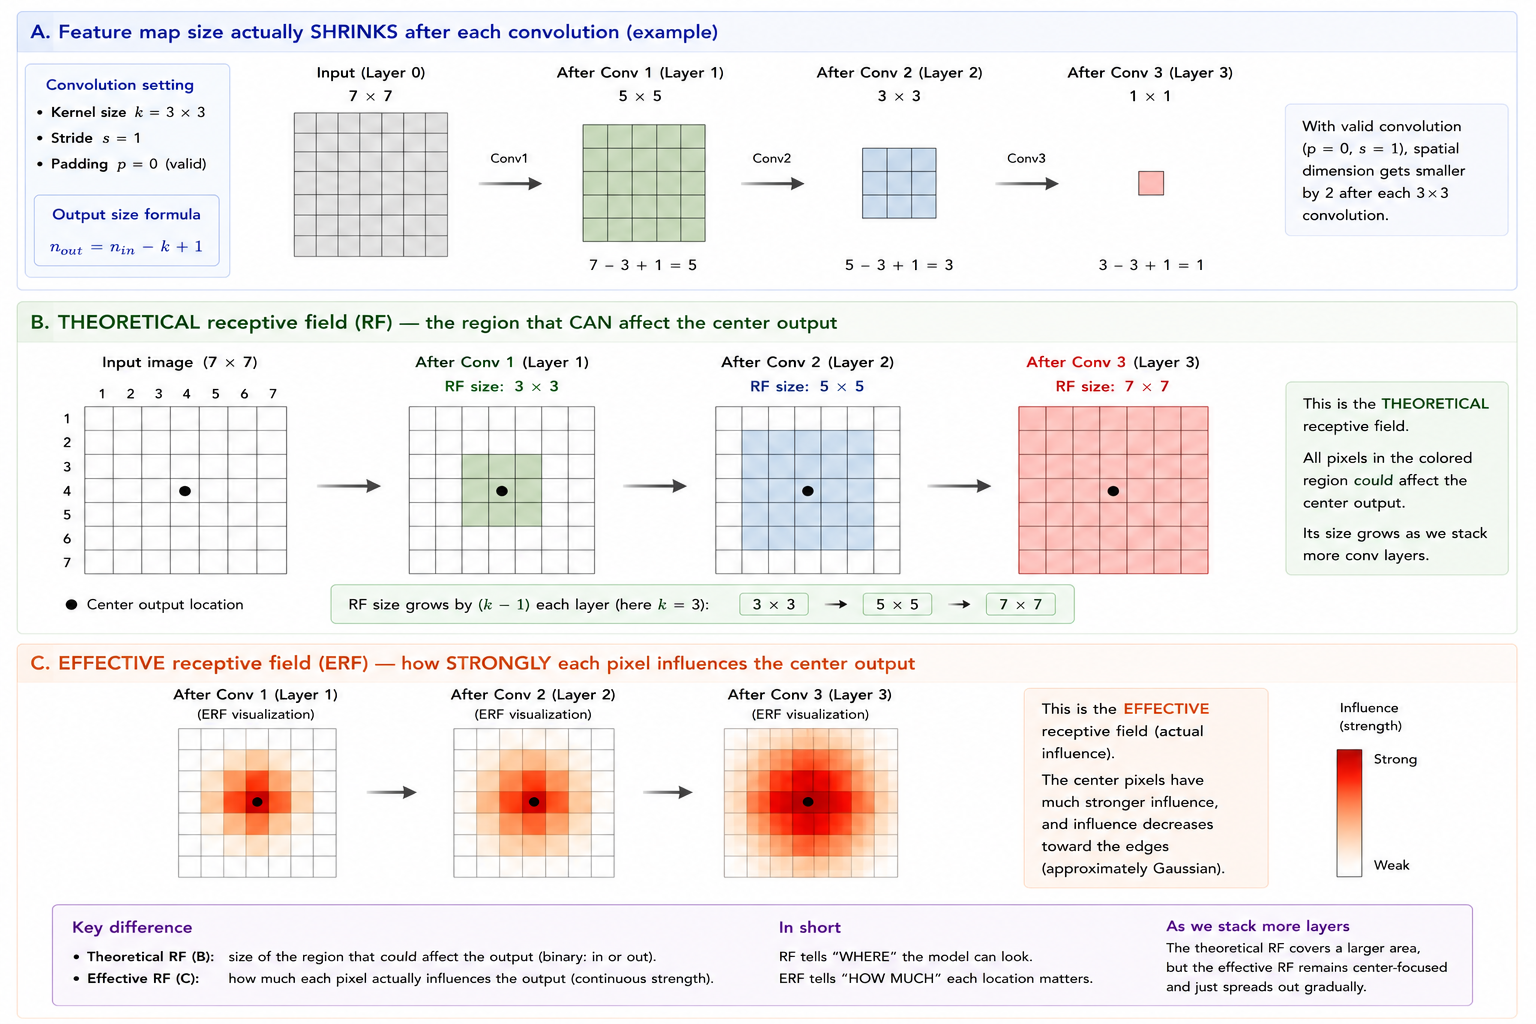

Use this formula to calculate the theoretical RF size after one layer:

$$r_{out} = r_{in} + (k - 1)*j_{in}$$

- $r_{in}$: RF size before the layer
- $r_{out}$: RF size after the layer
- $k$: kernel size
- $j_{in}$: spacing between neighboring features, measured in original input pixels
- $s$: stride, so $j_{out} = j_{in} * s$

In the figure, `k = 3` and `s = 1`. The input starts with `r = 1` and `j = 1`. After the first convolution, `r = 1 + (3 - 1) * 1 = 3`, so the RF is `3×3`. With two more `3×3` convolutions, the RF grows to `5×5` and then `7×7`.


### **Why Is a Larger Receptive Field Important?** <a id="toc-why-is-a-larger-receptive-field-important"></a>


A larger receptive field allows each feature to "see" more of the image.
If the receptive field is too small:

- the network may only observe small image fragments
- larger objects or patterns may not be recognized completely

This is especially important in tasks such as:

- image classification
- object detection
- image segmentation

A deeper CNN allows the network to capture both local details and global image structure.

### **Factors That Affect Receptive Field Size** <a id="toc-factors-that-affect-receptive-field-size"></a>


1. Number of Convolution Layers:
Adding more layers increases the receptive field.

2. Stride:
Larger stride values increase the receptive field more quickly, but reduce spatial resolution.

3. Pooling:
Pooling layers increase receptive field size through downsampling, but may lose some spatial detail.

4. Dilation:
Dilated convolutions insert spaces between kernel elements, allowing a larger receptive field without reducing resolution.

Let's see an example of how stride and adding layers affect the receptive field! First let's download the image:


In [69]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/RF_dot.png"

--2026-05-23 17:37:28--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/RF_dot.png
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30331 (30K) [image/png]
Saving to: ‘RF_dot.png.2’

RF_dot.png.2        100%[===================>]  29.62K  --.-KB/s    in 0.07s   

2026-05-23 17:37:29 (448 KB/s) - ‘RF_dot.png.2’ saved [30331/30331]



We load the image:


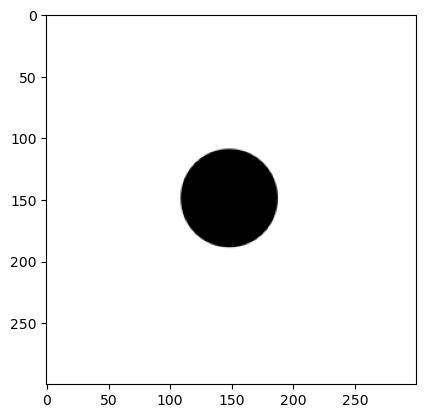

In [70]:
img_width = 300
img_height = 300

dot = PIL.Image.open("RF_dot.png")
dot = ImageOps.grayscale(dot)
# dot = PIL.ImageOps.invert(dot)
dot = dot.resize((img_width, img_height))
plt.imshow(dot, cmap="gray")
plt.show()

Below, we define the kernel and bias weights. For this section, we chose to use the average kernel, which takes the mean of the pixels. Also, we will use the helper function ```calc_rf``` defined previously to determine the theoretical RF size of a feature in each layer.


In [71]:
kernel = (1 / 9) * np.ones((3, 3, 1, 1))
b = np.array([0.0])

### **Model 1: Default Stride (1,1)** <a id="toc-model-1-default-stride-1-1"></a>
To begin, we will examine the output of a convolution layer using the default stride size of `(1,1)`. With a `3×3` kernel and stride `(1,1)`, each output feature observes a `3×3` region of the input image. Therefore, the receptive field size of the output features is `3×3`.


In [72]:
# Construct the model with no stride
model1 = Sequential()

model1.add(
    Conv2D(
        input_shape=(img_width, img_height, 1), filters=1, kernel_size=(3, 3)
    )
)

model1.layers[0].set_weights([kernel, b])

calc_rf(model1)

Layer 1: conv2d_14 
 Jump Size: 1
 Effective Receptive Field Size: 3
------


### **Model 2: Increased Stride** <a id="toc-model-2-increased-stride"></a>


Here we set the ```strides``` to 2 for the 2nd model.


In [73]:
# Construct the model with stride = 2
model2 = Sequential()

model2.add(
    Conv2D(
        input_shape=(img_width, img_height, 1),
        filters=1,
        kernel_size=(3, 3),
        padding="same",
        strides=2,
    )
)

model2.layers[0].set_weights([kernel, b])

calc_rf(model2)

Layer 1: conv2d_15 
 Jump Size: 2
 Effective Receptive Field Size: 3
------


Even when the stride size increases, the receptive field of each output feature remains `3×3` because the kernel size has not changed. Stride only changes how far the kernel moves between positions, not how much of the input image each kernel observes at one time.


### **Model 3: Increased Layers** <a id="toc-model-3-increased-layers"></a>


Lets see what happens with we increased the number of layers:


In [74]:
# Construct the model with multiple layers
model3 = Sequential()

model3.add(
    Conv2D(
        input_shape=(img_width, img_height, 1), filters=1, kernel_size=(3, 3)
    )
)
model3.add(Conv2D(filters=1, kernel_size=(3, 3), strides=4))
model3.add(Conv2D(filters=1, kernel_size=(3, 3), strides=5))

model3.layers[0].set_weights([kernel, b])
model3.layers[1].set_weights([kernel, b])
model3.layers[2].set_weights([kernel, b])

calc_rf(model3)

Layer 1: conv2d_16 
 Jump Size: 1
 Effective Receptive Field Size: 3
------
Layer 2: conv2d_17 
 Jump Size: 4
 Effective Receptive Field Size: 5
------
Layer 3: conv2d_18 
 Jump Size: 20
 Effective Receptive Field Size: 13
------


After adding more layers to the model, we clearly see the theoretical RF size for each feature increase in subsequent layers. In particular, the RF of layer 3 is significantly bigger than it would have been with stride 1 throughout the model.


### **Visualizing the Outputs** <a id="toc-visualizing-the-outputs"></a>


Let's compare the results to of the models:


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


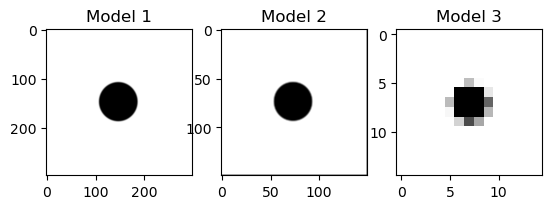

In [75]:
models = [model1, model2, model3]
dot_tensor = np.array(dot).reshape((1, img_width, img_height, 1))
fig, ax = plt.subplots(1, len(models))

for i in range(len(models)):
    plt.subplot(1, len(models), i + 1)
    output = models[i].predict(dot_tensor)
    output = output.reshape(output.shape[1], output.shape[2])
    plt.title("Model {}".format(i + 1))
    plt.imshow(output, cmap="gray")

As we increase the receptive field the subsequent images get smaller and smaller, but we can still make out the shape. This also decreased the number of parameters needed in the model.


## **Varied Input-Output Relationships** <a id="toc-varied-input-output-relationships"></a>


We previously only dealt with applying one kernel on one channel at a time, but that is quite inefficient to do since we often have access to multichannel (colored) image inputs, whose information can be learned jointly. Moreover, the convolutional layers are analogous to the hidden neurons in a neural network, and like a regular neural network, adding more neurons will improve results. Next, we will take a look at how increasing the number of channels can increase the information extracted.


Consider the following image:


In [76]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/channel_image.jpg"

--2026-05-23 17:37:29--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/channel_image.jpg
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37209 (36K) [image/jpeg]
Saving to: ‘channel_image.jpg.2’

channel_image.jpg.2 100%[===================>]  36.34K  --.-KB/s    in 0.1s    

2026-05-23 17:37:30 (338 KB/s) - ‘channel_image.jpg.2’ saved [37209/37209]



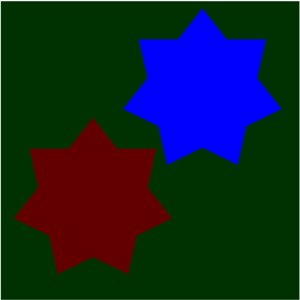

In [77]:
img_width = 300
img_height = 300

image = PIL.Image.open("channel_image.jpg").resize((img_width, img_height))
image

First, we define two filters we will use throughout the examples. The first filter is an edge kernel, which you have seen previously in the lab on padding, strides, and activation. This kernel helps us detect edges in the image. The second filter is a kernel that sharpens the image through creating greater contrast. Note that usually, in CNN, we would let the network learn the best filters automatically instead of defining them.


In [78]:
def edge_grad(shape, dtype=None):
    grad = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]).reshape(shape)

    return grad


def sharpen_grad(shape, dtype=None):
    grad = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]).reshape(shape)

    return grad

### **Single Input, Multiple Outputs** <a id="toc-single-input-multiple-outputs"></a>


Based on what you learned from past labs, you know how to apply a filter on a black and white image, so let's start with that. However, this time we will apply multiple filters on the grayscale image. 


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/SingleInMultiOut.png" width="600" alt="single input multiple output calculation">
<center>


The visual above, shows how outputs are calculated when there is a single channel but multiple filters. We can see that the depth of the output (number of channels it has) corresponds to the number of filters applied on the input. 


Here's a formula for calculating the width/height of one output channel:
$$n_{out} = \frac{n_{in} + 2p - k}{s} + 1$$

- $n_{out}$: width/height of output map
- $n_{in}$: width/height of input map
- $p$: convolution padding size
- $k$: convolution kernel width/height
- $s$: convolution stride size


As a first step, we convert the image to grayscale such that we work with a single channel as our input for now. Here, when the image is converted to grayscale, the stars are not visible anymore due to their RGB values being converted to a singular value representing brightness, which raises the concern of whether the filters will be able to detect any features.


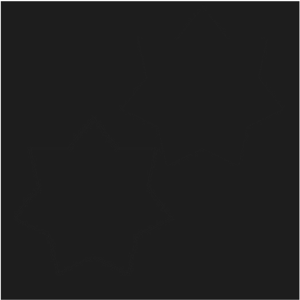

In [79]:
gray = ImageOps.grayscale(image)
img_tensor = np.array(gray).reshape(
    (1, img_width, img_height, 1)
)  # Convert to a tensor for model prediction
gray

Next, we define the desired kernels. Note here that the kernel takes on the size 3x3x1x2. This means that there are 2 filters, each with the dimension 3x3x1, where 1 represents the number of channels and 3x3 is the 2D kernel size. This shape is required because we are performing both convolutions in a single layer. The bias, set to 0 for both convolutions on the input, is represented by the variable `b`.


In [80]:
kernels = np.array([sharpen_grad((3, 3, 1, 1)), edge_grad((3, 3, 1, 1))])
kernels = kernels.reshape((3, 3, 1, 2))
b = np.array([np.array([0.0]), np.array([0.0])]).reshape(
    2,
)

Here, we define the Sequential model, adding one convolutional layer with 2 filters of size 3x3. After this, we specify the kernels and biases by the function `set_weights`. To see more information about the model built, use `summary()`.


In [81]:
model = Sequential()

model.add(
    Conv2D(
        filters=2,
        kernel_size=(3, 3),
        padding="same",
        input_shape=(img_width, img_height, 1),
    )
)

model.set_weights([kernels, b])

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 300, 300, 2)    │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In order to see how each filter is applied on the input, we use an additional model that specifies the desired output when given input from our previous model.


In [82]:
layer_outputs = [
    layer.output for layer in model.layers
]  # Extracts the outputs of the layer
activation_model = Model(
    inputs=model.inputs, outputs=layer_outputs
)  # Creates a model that will return these outputs, given the model input

activation_model.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 300, 300, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 300, 300, 2)    │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

Now that we have set up the model structure, we feed the image tensor as input to the activation model to separate the outputs from individual kernels.


In [83]:
activations = activation_model.predict(
    img_tensor
)  # Obtain the outputs (activations) from our model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [ ]:
filter_outputs = (
    activations[0][0] if isinstance(activations, list) else activations[0]
)
# Extract the outputs from the first (in this case, the only) layer of the model
print(filter_outputs.shape)

(300, 300, 2)


The output shape confirms that the model correctly applied the two filters on the input as the output depth is 2 - one dimension for each filter. Using the formula above, we also know that the width and height are (1)*300+2(1)-3 + 1 = 300. Since each filter output is a tensor, we can also display their weights by directly indexing the object:


In [85]:
# Display weights of the first filter of this layer
filter_outputs[:, :, 0]

array([[-553., -632., -495., ..., -488., -586., -253.],
       [ 947.,  925., 1105., ..., 1109.,  888., -174.],
       [ 145.,   98.,  281., ...,  273.,  524., -181.],
       ...,
       [-101., -151.,   33., ...,   27.,  417., -176.],
       [-153., -252., -106., ..., -109.,  305., -244.],
       [  73.,   57.,   61., ...,   45.,  591.,    0.]], dtype=float32)

We can also visualize the outputs from each convolution:


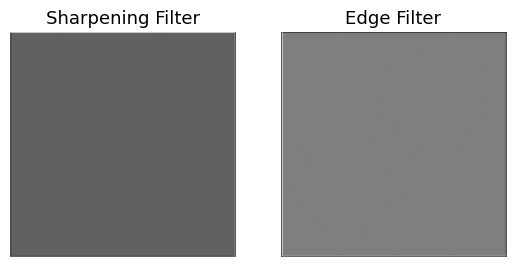

In [86]:
# Display the filter outputs
names = ["Sharpening Filter", "Edge Filter"]
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(filter_outputs[:, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"{names[i]}", fontsize=13)

We see that given a grayscale image in which the shapes blended in completely with the background, the sharpening and edge filters can't detect any features that were apparent in the colored image.


### **Multiple Inputs, Single Output** <a id="toc-multiple-inputs-single-output"></a>


So, what if we used a colored image instead? Will the network be better at sharpening the image? Before moving onto utilizing multiple filters, let's see how the output is calculated when we have one filter applied on multiple channels, such as RGB.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/MultiInSingleOut.png" width="600" alt="multiple input single output calculation">
<center>


How a filter is applied on multi-channel input is quite similar to the single channel case. What's different is that now, the depth of the filter will correspond to the number of input channels, so one 2D kernel is designated for one channel. The convolved result for each channel is then added together to form a single output channel.


#### **Exercise: Reshape the Image**


In [87]:
# Using the RGB image from before, convert it to a numpy array
# and reshape it to be 300x300x3, where 3 is for the three channels.
# WRITE YOUR CODE HERE
img_tensor = np.array(image).reshape((1, img_width, img_height, 3))

<details><summary>Solution</summary>
    <code>img_tensor = np.array(image).reshape((1, img_width, img_height, 3))</code>
</details>


Again, we define the filter we hope to use. In this case, the kernel is of shape 3x3x3x1 because we want one 3x3 filter for each of the 3 input channels. Note that these three filters take on the same value since we want to apply the same convolution on all the channels. With one filter involved for convolution, we specify one bias value.


In [88]:
kernel = np.array(
    [
        sharpen_grad((3, 3, 1, 1)),
        sharpen_grad((3, 3, 1, 1)),
        sharpen_grad((3, 3, 1, 1)),
    ]
)
kernel = kernel.reshape((3, 3, 3, 1))
b = np.array([0.0])

In [89]:
model = Sequential()

model.add(
    Conv2D(
        filters=1,
        kernel_size=(3, 3),
        padding="same",
        input_shape=(img_width, img_height, 3),
    )
)

model.set_weights([kernel, b])

model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 300, 300, 1)    │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28 (112.00 B)

 Trainable params: 28 (112.00 B)

 Non-trainable params: 0 (0.00 B)

The output shape of the layer can be seen in the model summary above. It matches what we expect based on the padding, stride, kernel size, and number of filters used in the convolution layer.

We can also visualize the output feature map. Since the model uses only one filter, the layer produces a single output channel, so no additional model is needed to separate multiple filter outputs. However, the predicted output must be reshaped into a 2D array before it can be displayed as an image.

In [90]:
output = model.predict(img_tensor)
output = output.reshape((img_width, img_height))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In this case, `output` directly shows us the result of applying a filter on the multichannel input.


In [91]:
# View values of the output tensor
output

array([[1093.,  295.,  408., ...,  431.,  312.,  986.],
       [1699.,  272.,  536., ...,  568.,  302., 1477.],
       [1805.,   10.,  430., ...,  468.,   59., 1457.],
       ...,
       [1832.,  -36.,  402., ...,  454.,    7., 1446.],
       [1815.,    8.,  443., ...,  474.,   57., 1456.],
       [1205.,   17.,  307., ...,  319.,   50.,  974.]], dtype=float32)

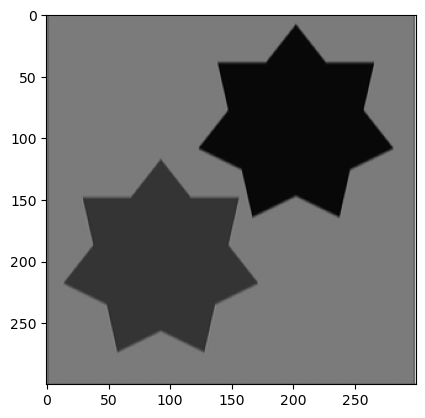

In [92]:
plt.imshow(output, cmap="gray")

It is evident here that applying a single filter on the colored image already performs better than applying two filters on the grayscale. You can see the stars now!


### **Multiple Inputs, Multiple Outputs** <a id="toc-multiple-inputs-multiple-outputs"></a>


Now for the most complex relationship -  applying multiple filters on multichannel inputs all at once. How is convolution performed, and what would the output look like? Combining knowledge from the previous two subsections, you can probably guess how we calculate the output based on multichannel inputs with multiple filters. Each output channel is calculated the same way as the "Multiple Inputs, Single Output" case. The number of output channels corresponds to the number of filters applied.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/MultiInMultiOut.png" width="600" alt="multiple input multiple output calculation">
<center>


It is evident in the visual above that the number of output channels correspond to the number of filters we have, and each channel is the summation of convolution on the input channels for a single kernel. Let's apply the method to a color image.


In TensorFlow / Keras, CNN models expect image input in this format:

(batch_size, height, width, channels)

In [93]:
img_tensor = np.array(image).reshape((1, img_width, img_height, 3))

We will take our color image and apply the filters to get two outputs. Here, we have 3 input channels x 2 outputs, meaning that we need 6 filter channels total, 3 for each filter. We define the filter here:


In [94]:
kernel = np.zeros((3, 3, 3, 2))

kernel[0] = np.dstack([sharpen_grad((3, 3, 1)), edge_grad((3, 3, 1))])
kernel[1] = np.dstack([sharpen_grad((3, 3, 1)), edge_grad((3, 3, 1))])
kernel[2] = np.dstack([sharpen_grad((3, 3, 1)), edge_grad((3, 3, 1))])

kernel = kernel.reshape((3, 3, 3, 2))

#### **Exercise: Define biases**
If we have one bias per operation on the input, what does our bias object look like?  Set the bias to 0.


In [95]:
# WRITE YOUR CODE HERE
b = np.array([np.array([0.0]), np.array([0.0])]).reshape(
    2,
)

We proceed to define the model:


In [96]:
model = Sequential()

model.add(
    Conv2D(
        filters=2,
        kernel_size=(3, 3),
        padding="same",
        input_shape=(img_width, img_height, 3),
    )
)

model.set_weights([kernel, b])

model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 300, 300, 2)    │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56 (224.00 B)

 Trainable params: 56 (224.00 B)

 Non-trainable params: 0 (0.00 B)

We assign the the pre-made filters:


In [ ]:
layer_outputs = [layer.output for layer in model.layers]
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)
activations = activation_model.predict(img_tensor)
filter_outputs = (
    activations[0][0] if isinstance(activations, list) else activations[0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


Here, you can see that no matter how many channels we have as input, the output dimension doesn't depend on it.


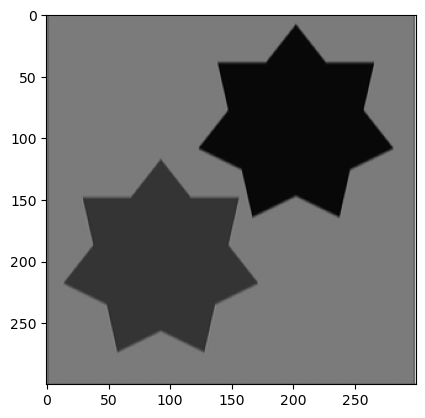

In [98]:
plt.imshow(
    filter_outputs[:, :, 0], cmap="gray"
)  # Print out the convolved result of the first filter

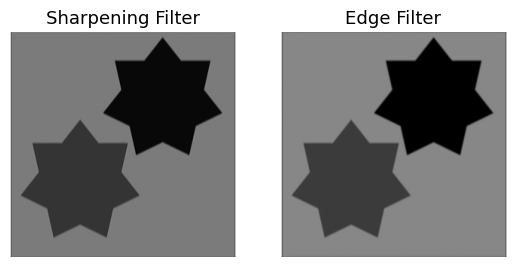

In [99]:
# Display the filter outputs
names = ["Sharpening Filter", "Edge Filter"]
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(filter_outputs[:, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"{names[i]}", fontsize=13)

From the two outputs, we notice that they produce very similar results, which is reasonable considering how simple the shape edges are.


The following code builds a simple CNN containing a single convolution layer with two filters.

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer (Conv2D)             │ (None, 300, 300, 2)    │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56 (224.00 B)

 Trainable params: 56 (224.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


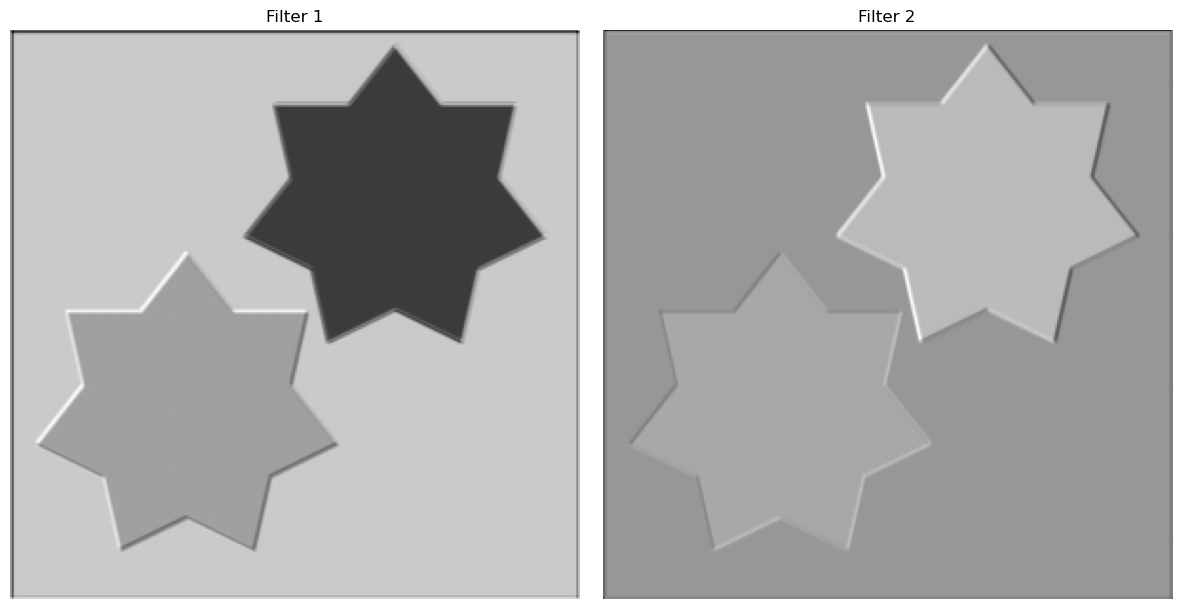

In [100]:
# Build CNN model
model = Sequential(
    [
        Conv2D(
            filters=2,
            kernel_size=(3, 3),
            padding="same",
            kernel_initializer="he_uniform",
            input_shape=(img_width, img_height, 3),
            name="conv_layer",
        )
    ]
)

# Display model summary
model.summary()


# Generate feature maps
feature_maps = model.predict(img_tensor)

# Remove batch dimension
feature_maps = feature_maps[0]

# Number of filters
n_filters = feature_maps.shape[-1]

# Plot outputs from all filters
plt.figure(figsize=(6 * n_filters, 6))

for i in range(n_filters):

    plt.subplot(1, n_filters, i + 1)

    plt.imshow(feature_maps[:, :, i], cmap="gray")

    plt.title(f"Filter {i+1}")

    plt.axis("off")

plt.tight_layout()
plt.show()

## **Deeper CNNs** <a id="toc-deeper-cnns"></a>


In the last lab, you had a preview of multi-layered CNNs. Now with a better understanding of the relationship between input and output size, we can decipher where the output shapes of each layer come from when training the network.


### **Why do we want multiple layers?** <a id="toc-why-do-we-want-multiple-layers"></a>


The benefit of multiple layers is that each layer can be responsible for detecting a certain set of features, which will help train the model better than if we only had a single layer. Moreover, we can specify different activation functions for each convolution layer. Let's see that in action with an example.


### **Example: Preparing a CNN for Flower Classification** <a id="toc-example-preparing-a-cnn-for-flower-classification"></a>


We will use our flower images from the image convolution lab. However, this time, we want to use them to train a CNN model for classification. Hence, we will utilize a training and test set.
https://www.tensorflow.org/tutorials/load_data/images


In [101]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/flower_photos.tgz"
data_dir = keras.utils.get_file(
    origin=dataset_url, fname="flower_photos", untar=True
)

data_dir = pathlib.Path(data_dir)
if not list(data_dir.glob("*/*.jpg")) and (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

for folder in data_dir.glob("[!LICENSE]*"):
    print(
        "The",
        folder.name,
        "folder has",
        len(list(folder.glob("*.jpg"))),
        "pictures",
    )
image_count = len(list(data_dir.glob("*/*.jpg")))
print(image_count, "total images")

The roses folder has 641 pictures
The tulips folder has 799 pictures
The daisy folder has 633 pictures
The sunflowers folder has 699 pictures
The dandelion folder has 898 pictures
3670 total images


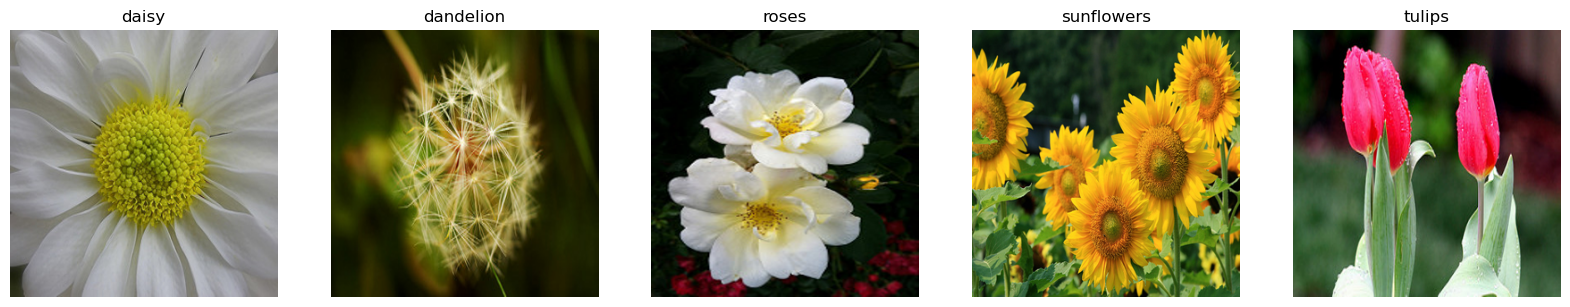

In [102]:
pics = list()
pics_arr = list()
p_class = list()

img_width = 300
img_height = 300

plt.figure(figsize=(20, 5))
for idx, folder in enumerate(sorted(data_dir.glob("[!LICENSE]*"))):
    cat = sorted(folder.glob("*.jpg"))
    pic = PIL.Image.open(cat[0]).resize((img_width, img_height))
    pic_arr = np.array(pic)
    clss = folder.name

    plt.subplot(1, 5, idx + 1)
    plt.imshow(pic)
    plt.title(clss)
    plt.axis("off")

    pics.append(pic)
    pics_arr.append(pic_arr)
    p_class.append(clss)

#### **Exercise: Define the model and add the first layer**

Define the Sequential model and add the following layer to our classifier:
1. Convolutional layer with 3 input channels, three 3x3 filters, even padding, and relu activation function.


In [103]:
# WRITE YOUR CODE HERE
classifier = Sequential()
classifier.add(
    Conv2D(
        3,
        (3, 3),
        padding="same",
        input_shape=(img_width, img_height, 3),
        activation="relu",
    )
)

#### **Exercise: Add additional layers**
In Keras, you can simply call `add()` to add multiple layers to the Sequential model you've defined. 
1. Convolutional layer with two 3x3 filters and sigmoid activation function.
2. Convolutional layer with six 5x5 filters, stride = 4, even padding, and relu activation function.
3. Max pooling layer with size 2x2.


In [104]:
# WRITE YOUR CODE HERE
classifier.add(Conv2D(2, (3, 3), activation="sigmoid"))
classifier.add(Conv2D(6, (5, 5), strides=4, padding="same", activation="relu"))
classifier.add(MaxPooling2D(pool_size=(2, 2)))

### **Flattening** <a id="toc-flattening"></a>


Before classification, the CNN output must be converted into a 1D feature vector. This step is called **flattening**.

Flattening keeps all values but removes the spatial shape. For example, a `28 × 28` feature map becomes a vector with `28 × 28 = 784` values.

If there are multiple channels, multiply by the number of channels: `28 × 28 × 3 = 2352` values.

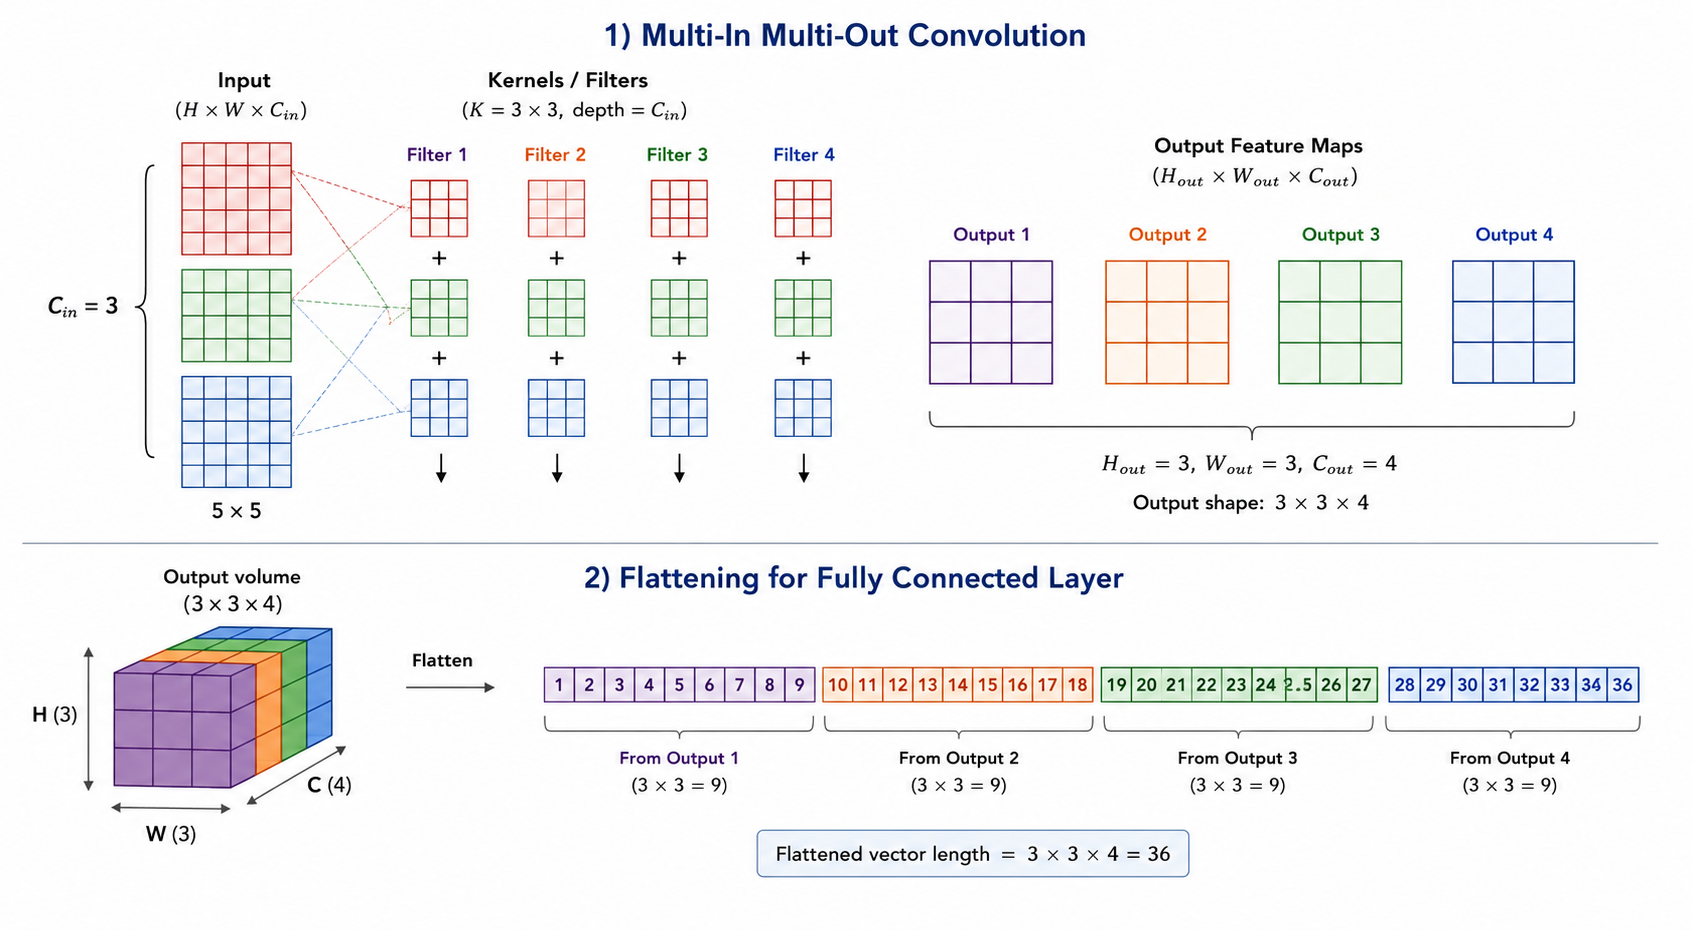


In [105]:
# Add a flattening layer
classifier.add(Flatten())

In [106]:
classifier.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 300, 300, 3)    │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 298, 298, 2)    │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 75, 75, 6)      │           306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 37, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8214)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446 (1.74 KB)

 Trainable params: 446 (1.74 KB)

 Non-trainable params: 0 (0.00 B)

From the summary above, we see that the shape of the input (the output of the previous layer) is 37x37x6. The shape of the flattening layer output is 8214x1 = 37\*37\*6, demonstrating that the process was successful. 


`GlobalAveragePooling2D()` summarizes each feature map by calculating its average value. Instead of keeping every spatial value like `Flatten()` does, it reduces each learned feature map to a single number. This creates a smaller feature vector, reduces the number of parameters in the dense layers, and can help lower the risk of overfitting. For transfer learning, `GlobalAveragePooling2D()` is often preferred because it keeps the most important feature information while making the model simpler and more efficient.

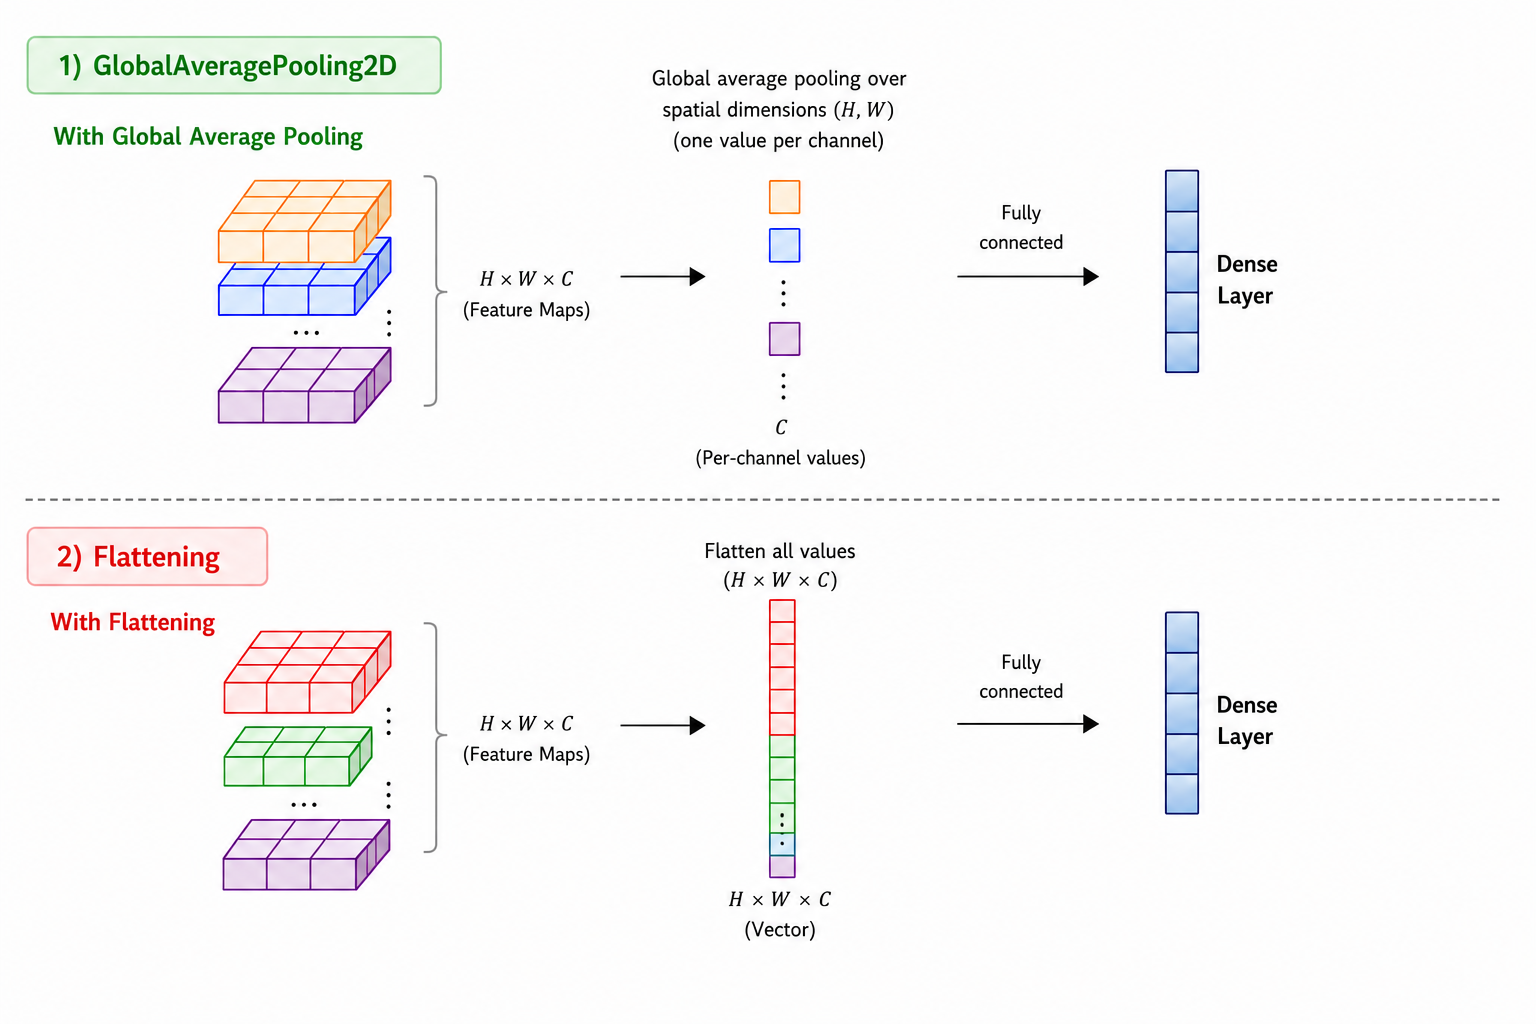

### **Dense Layers** <a id="toc-dense-layers"></a>


Before making predictions, a CNN usually includes one or more dense (fully connected) layers. These layers use the features extracted by the convolutional and pooling layers to classify an image.

The first dense layer takes a flattened 1D array as input. It computes weighted sums of all input features and then applies an activation function. Because every neuron is connected to all input features, this layer is called a fully connected layer.

The final dense layer is responsible for producing the prediction. When the model has more than two classes, the softmax activation function is commonly used. Softmax converts the outputs into probabilities for each class, where all probabilities sum to 1. The class with the highest probability is selected as the final prediction for the input image.

Let's add two dense layers: one to connect with the flattened layer and the other to prepare the tensor for classification. Note that `units=5` for the second one because we have 5 categories of flowers total.


In [107]:
classifier.add(Dense(units=512, activation="relu"))

classifier.add(Dense(units=5, activation="softmax"))

In [108]:
classifier.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 300, 300, 3)    │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 298, 298, 2)    │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 75, 75, 6)      │           306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 37, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8214)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,206,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,209,091 (16.06 MB)

 Trainable params: 4,209,091 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

That wraps up this lab! Knowing all the components of a convolutional neural network, you're now ready to use it for advanced applications - classification, object detection, and more. We'll specifically go into how to train your model for a classification task in the next lab.


## **Authors**


[Cindy Huang](https://www.linkedin.com/in/cindy-shih-ting-huang/) is an incoming 4th year undergraduate at the University of Toronto studying data science. She has a passion for using machine learning to improve user experience.

Su Wu


### **Other Contributors**


[Joseph Santarcangelo](https://www.linkedin.com/in/joseph-s-50398b136/) has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2022-06-13|0.1|Cindy|Create first draft|
|2022-06-29|0.2|Joseph|Edited lab||2022-09-07|0.2|Steve Hord|QA pass edits|
| 2026-05-23        | 0.2     | Su Wu| Documentation and script edit    |


Copyright © 2022 IBM Corporation. All rights reserved.
